# Germany 2018 wind–solar complementarity: reader-first overview

**Research question.** How do German wind and solar resource proxies vary in time and space,
how complementary are they, and how sensitive are low-output periods to spatial weighting and
temporal resolution?

This concise guide assumes comfort with gridded climate data but no energy background. It reads
only committed compact assets and makes no downloads. The reproducible details are in notebooks
01–06.

## 1. From reanalysis to Germany

**COSMO-REA6** is a regional atmospheric reanalysis: a model constrained by observations. Think
of it like an ocean reanalysis, but for the atmosphere. Daily 2018 fields are first cropped to a
DACH rectangle. Germany, Austria, and Switzerland are then selected with political polygons.
A model cell belongs to a country when its **centre** is inside that polygon. Border and coastal
cells can straddle two surfaces, so this is reproducible but not fractional-area masking.

The analysis chain is: **COSMO-REA6 weather → simplified weather-to-power conversion →
area-weighted resource proxy → OPSD capacity-weighted modelled fleet proxy → SMARD observed
national grid-fed generation → November 2018 hourly resolution case study**. The atmospheric
inputs are model cells, not turbines; SMARD is a national time series, not a second grid.

## 2. From weather fields to capacity-factor proxies

**GHI (global horizontal irradiance)** is direct horizontal plus diffuse horizontal shortwave
irradiance: `ASWDIR_S + ASWDIFD_S`, in W m⁻². It is solar power arriving per horizontal square
metre. A simple temperature-aware rule converts GHI to a **solar capacity-factor proxy**.

Wind speed is formed from the 10 m vector, extrapolated to 100 m with a power law, and passed
through a generic turbine curve. Because that curve is nonlinear, CF calculated from a daily-mean
wind speed is not generally the same as averaging CF calculated from hourly wind speeds. Both
products are weather-to-power **proxies**, not measured fleet generation. Tilt, snow, turbine
type, wakes, availability, and other details are omitted.

**Capacity factor (CF)** is energy divided by rated capacity times duration. Example: 1,200 MWh
from 200 MW over 24 h gives `1200 / (200 × 24) = 0.25`. CF is dimensionless. A 50/50 hybrid is
`0.5 × wind CF + 0.5 × solar CF`; for wind 0.30 and solar 0.10, hybrid CF is 0.20. The weights are
equal rated capacities, not equal energy and not Germany's historical mix.

## 3. Compact 2018 results

Country means use approximate cell-area weights (`cos(latitude)`). Thus an equal physical area
has equal influence, whether or not a plant is installed there. The next table is calculated
from the stored daily country series so the displayed values remain the source of each statement.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
ASSETS = ROOT / "app_assets" / "2018"
daily = pd.read_parquet(ASSETS / "cosmo_rea6_dach_2018_daily_country_timeseries.parquet")
de = daily[daily["country"] == "de"].copy().sort_values("time")
de["time"] = pd.to_datetime(de["time"]).dt.normalize()
summary = pd.Series({
    "unique German dates": de["time"].nunique(),
    "mean wind CF proxy": de["wind_cf"].mean(),
    "mean solar CF proxy": de["solar_cf"].mean(),
    "mean 50/50 hybrid CF": de["combined_cf"].mean(),
    "wind–solar correlation": de["wind_cf"].corr(de["solar_cf"]),
    "hybrid 10th percentile": de["combined_cf"].quantile(0.10),
}, name="Germany 2018")
summary.to_frame().round(3)

,Germany 2018
unique German dates,365.000
mean wind CF proxy,0.155
mean solar CF proxy,0.128
mean 50/50 hybrid CF,0.142
wind–solar correlation,-0.373
hybrid 10th percentile,0.056


**Interpret carefully.** Correlation measures co-variation. Negative correlation can smooth a
portfolio because one source often offsets the other, but it does not prevent both being low.
A one-year mean or correlation is not a climatology, trend, or return-period estimate.

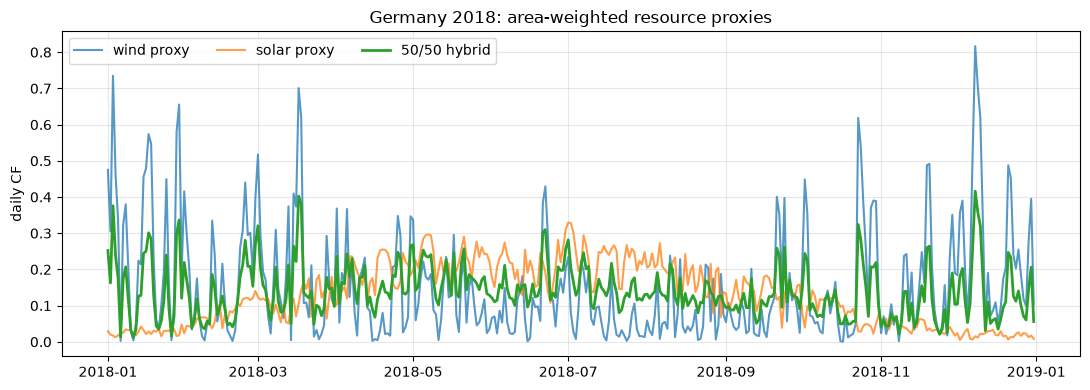

In [2]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(de["time"], de["wind_cf"], label="wind proxy", alpha=.75)
ax.plot(de["time"], de["solar_cf"], label="solar proxy", alpha=.75)
ax.plot(de["time"], de["combined_cf"], label="50/50 hybrid", linewidth=2)
ax.set(ylabel="daily CF", title="Germany 2018: area-weighted resource proxies")
ax.grid(alpha=.3); ax.legend(ncol=3); plt.tight_layout(); plt.show()

**Interpretation.** Wind and solar have distinct seasonal and day-to-day patterns. Their
hypothetical equal-rated-capacity combination smooths some variability but does not remove
periods when both resource proxies are low. Daily values do not resolve hourly ramps.

## 4. Complementarity and Dunkelflaute

Complementarity is tested with raw and seasonally adjusted correlation, mix sweeps, variance,
low percentiles, and event sensitivity. A **Dunkelflaute** here is at least two consecutive days
with 50/50 hybrid CF below 0.10. This is a transparent screening definition, not loss of load:
demand, storage, imports, transmission, and dispatchable supply are absent. Event counts and
duration depend on threshold, weighting, and conversion bias. One year cannot establish event
frequency or rarity.

In [3]:
events = pd.read_parquet(ASSETS / "cosmo_rea6_dach_2018_dunkelflaute_events.parquet")
events[events["country"] == "de"].head(8)

,country,start,end,duration_days,threshold_combined_cf
81,de,2018-01-10,2018-01-12,3,0.1
82,de,2018-01-20,2018-01-22,3,0.1
83,de,2018-01-25,2018-01-27,3,0.1
84,de,2018-02-03,2018-02-04,2,0.1
85,de,2018-02-06,2018-02-10,5,0.1
86,de,2018-02-13,2018-02-14,2,0.1
87,de,2018-02-16,2018-02-20,5,0.1
88,de,2018-03-05,2018-03-06,2,0.1


**Interpretation.** Event dates and durations follow the stated CF < 0.10 and ≥2-day definition.
Counts are sensitive to threshold, weighting and conversion bias. They describe sustained low
modelled renewable-resource output, not electricity shortages.

## 5. Validation with SMARD and bias correction

SMARD is the Bundesnetzagentur national electricity-market data portal. The stored CSV contains
365 German daily records per technology from filters 4067 (onshore wind) and 4068 (PV), with
generation and CF based on published capacity denominators. It has no grid cells or plant sites.
Attribution is Bundesnetzagentur SMARD, CC BY 4.0.

Comparison asks separately whether peaks and troughs occur at the right time (correlation) and
whether the level is right (bias, MAE, RMSE). The simple mean-ratio correction scales model CF by
observed mean divided by model mean. It removes fitted 2018 mean bias, but cannot repair timing,
distribution shape, or physics. Because fitting and evaluation use the same year, it is a
**diagnostic sensitivity experiment—same-year calibration/evaluation; not independent validation**.

In [4]:
smard = pd.read_csv(ASSETS / "smard_de_2018_daily.csv", parse_dates=["date"])
pd.DataFrame({
    "records": [len(smard), len(smard)],
    "mean observed CF": [smard["wind_onshore_cf"].mean(), smard["solar_cf"].mean()],
    "mean area proxy CF": [de["wind_cf"].mean(), de["solar_cf"].mean()],
}, index=["onshore wind", "solar"]).round(3)

,records,mean observed CF,mean area proxy CF
onshore wind,365,0.194,0.155
solar,365,0.104,0.128


**Interpretation.** Correlation tests whether high and low days align; bias, MAE and RMSE test
level and error magnitude. Differences may involve spatial deployment, conversion assumptions,
operational effects or the capacity denominator, but this analysis does not attribute individual
errors to a single cause.

## 6. OPSD capacity weighting

Open Power System Data (OPSD) harmonizes open power-system data. The processed plant register
uses technology/source, electrical capacity MW, coordinates, commissioning/decommissioning dates,
and federal state to retain coordinate-valid onshore-wind and PV units operating during 2018.
Capacity is summed into nearby German reanalysis cells. Record count is not capacity coverage:
many small PV records and fewer wind records can represent similar MW.

Area weighting asks, “what weather did German land experience?” Capacity weighting asks, “what
weather did mapped installed MW experience?” It affects wind more because wind capacity is more
spatially concentrated. Map colour `log(1+MW)` makes small and large cells visible: 0, 9, and
99 MW map to about 0, 2.30, and 4.61. Colour differences are logarithmic, not direct MW gaps.

In [5]:
with open(ASSETS / "cosmo_rea6_de_2018_capacity_weighting_qc.json", encoding="utf-8") as f:
    qc = json.load(f)
pd.DataFrame({
    "plant records": qc["plant_records"],
    "mapped MW": qc["mapped_capacity_mw"],
    "published end-2018 MW": qc["published_end_2018_capacity_mw"],
    "capacity coverage": qc["mapped_capacity_coverage_fraction"],
    "occupied model cells": qc["occupied_grid_cells"],
}).T

,solar,wind
plant records,1724519.000,21511.0000
mapped MW,44008.608,42185.9390
published end-2018 MW,45277.000,52565.0000
capacity coverage,0.972,0.8026
occupied model cells,5582.000,2376.0000


## 7. Area, fleet, and observation in one table

This table keeps the scientific objects separate. Area weighting is the land-resource
baseline; capacity weighting is the modelled fleet proxy; SMARD is observed national
grid-fed generation. Capacity weighting improves some measures, but wind correlation and RMSE
become slightly worse, so it is not a uniform skill improvement.

In [6]:
capacity = pd.read_parquet(ASSETS / "cosmo_rea6_de_2018_daily_capacity_weighted.parquet")
capacity["time"] = pd.to_datetime(capacity["time"]).dt.normalize()
smard["date"] = pd.to_datetime(smard["date"]).dt.tz_localize(None).dt.normalize()
joined = de.merge(capacity, on="time").merge(smard, left_on="time", right_on="date")

def validation_row(observed, modelled):
    error = modelled - observed
    return [modelled.mean(), modelled.corr(observed), error.mean(), error.abs().mean(), (error.pow(2).mean()) ** .5]

result_table = pd.DataFrame([
    validation_row(joined["wind_onshore_cf"], joined["wind_cf"]),
    validation_row(joined["wind_onshore_cf"], joined["wind_cf_capacity_weighted"]),
    validation_row(joined["solar_cf_y"], joined["solar_cf_x"]),
    validation_row(joined["solar_cf_y"], joined["solar_cf_capacity_weighted"]),
], index=pd.MultiIndex.from_tuples([
    ("wind", "area"), ("wind", "capacity"), ("solar", "area"), ("solar", "capacity")
], names=["technology", "weighting"]), columns=["mean CF", "correlation", "bias", "MAE", "RMSE"])
result_table.round(3)

mean CF  correlation   bias    MAE   RMSE
technology weighting                                           
wind       area         0.155        0.945 -0.039  0.053  0.064
           capacity     0.205        0.940  0.011  0.052  0.067
solar      area         0.128        0.980  0.024  0.026  0.034
           capacity     0.128        0.983  0.024  0.025  0.033

**Coverage and events.** Coordinate-valid mapped OPSD capacity is 42,185.939 MW wind out of
52,565 MW (80.3%; 21,511 records in 2,376 occupied cells) and 44,008.608 MW solar out of
45,277 MW (97.2%; 1,724,519 records in 5,582 occupied cells). With the same national 50/50 CF
below 0.10 for at least two days definition, area weighting gives 22 events / 10 longest days /
3.052 CF-days severity; capacity weighting gives 16 / 9 / 1.953.

**2018 in one chain.** COSMO weather cells → simple resource-to-CF conversion → German country
mask → area-weighted baseline → SMARD national validation → OPSD installed-MW mapping →
capacity-weighted fleet proxy → weighting-sensitive event comparison. Each arrow changes what
is represented; none turns this prototype into observed plant-level production.

## 8. What the November 2018 hourly case study adds

Notebook 06 uses 720 COSMO-REA6 labels from 01:00 UTC on 1 November through 00:00 UTC on
1 December. Each value represents the hour ending at its label, so midnight is grouped with the
preceding day. This one-month test reveals the solar day/night cycle, consecutive-hour ramps, and
threshold crossings hidden by daily means. Hourly SMARD observations provide exact UTC-aligned national validation of timing, levels, ramps, daylight behavior, and low-output resource classification.

In [7]:
hourly = pd.read_parquet(ASSETS / "cosmo_rea6_de_201811_hourly.parquet")
with open(ASSETS / "cosmo_rea6_de_201811_hourly_qc.json", encoding="utf-8") as f:
    hourly_qc = json.load(f)
hourly_summary = pd.DataFrame({
    "area": [hourly.wind_cf_area.mean(), hourly.solar_cf_area.mean(), hourly.hybrid_cf_area.mean(),
             hourly_qc["low_output_screening"]["area"]["low_hours"],
             hourly_qc["low_output_screening"]["area"]["longest_run_hours"]],
    "capacity": [hourly.wind_cf_capacity.mean(), hourly.solar_cf_capacity.mean(), hourly.hybrid_cf_capacity.mean(),
                 hourly_qc["low_output_screening"]["capacity"]["low_hours"],
                 hourly_qc["low_output_screening"]["capacity"]["longest_run_hours"]],
}, index=["mean wind CF", "mean solar CF", "mean hybrid CF", "low hours", "longest run (h)"])
hourly_summary.round(4)

,area,capacity
mean wind CF,0.1708,0.2273
mean solar CF,0.0410,0.0417
mean hybrid CF,0.1059,0.1345
low hours,401.0000,326.0000
longest run (h),45.0000,22.0000


**Observed validation.** Notebook 06 uses SMARD hourly MWh aligned to COSMO interval starts in UTC; no fitting or scaling uses observations. Its observed hybrid is a hypothetical equal-rated-capacity portfolio used for low-output screening, not actual combined generation or electricity-shortage validation. OPSD remains the plant-location weighting source; its time-series package is not used as independent second validation because provenance may overlap.

**Resolution result.** Hourly-derived daily wind remains highly correlated with the daily-mean route
(`r≈0.993`) but is about 0.031–0.033 CF higher, illustrating nonlinear wind conversion before
versus after averaging. Solar agrees almost exactly (`r≈0.999995`, bias about −0.00024) while
exposing its diurnal envelope. Hybrid ramps and low-hour runs are visible, but the `<0.10`
threshold includes nighttime solar zeros, so runs naturally fragment with daylight and must not
be equated with daily events or electricity shortages.

## 9. What is and is not justified

**Supported for this prototype:** the 2018 stored data pass basic coverage/range checks; weather
explains much national day-to-day timing; wind and solar can smooth one another; level errors
matter; plant geography changes the fleet proxy, especially wind.

**Not supported:** a bankable yield estimate, causal attribution of individual errors, actual
German hybrid generation, adequacy or blackout risk, climate trend, return period, future-climate
conclusion, or a universal Dunkelflaute frequency.

Main limitations are one full year at daily resolution plus one hourly month, generic conversion
curves, centre-point country masks, approximate area weights, static/coordinate-incomplete plant
mapping, year-end observed capacity denominators, and no demand, storage, grid, losses, or
operations model.

## 10. Reading path: notebooks 01–06

1. **01 — domain reference:** grid, pre-crop, country mask, and source-field QC.
2. **02 — Germany EDA:** distributions, seasonality, persistence, and spatial patterns.
3. **03 — complementarity:** correlations, mix sweeps, low-output thresholds, and events.
4. **04 — validation:** SMARD timing/level errors, monthly bias, and correction sensitivity.
5. **05 — capacity weighting:** OPSD coverage and area-versus-fleet weighting.
6. **06 — hourly case study:** November diurnal cycles, ramps, and resolution-sensitive low runs.

For every figure ask: *What is one point or cell? What are the units? What was averaged? What
is the denominator? Is colour linear? Is the claim about timing, amplitude, or both? Could the
result change with threshold, season, mask, or weighting?*

## Compact glossary

| Term | Simple meaning |
|---|---|
| Reanalysis | Weather model reconstructed with observational constraints. |
| GHI | Direct-horizontal plus diffuse-horizontal solar irradiance (W m⁻²). |
| CF | Output divided by rated output over the same time. |
| Proxy | Simplified weather-derived estimate, not observed generation. |
| Hybrid CF | Rated-capacity-weighted wind and solar CF. |
| Area weighting | Cells influence a mean by approximate physical area. |
| Capacity weighting | Cells influence a mean by mapped installed MW. |
| Complementarity | One resource tends to offset another in time. |
| Dunkelflaute | A defined sustained low-wind/low-solar event. |
| Bias | Mean(model − observation); positive means model is high. |
| SMARD | Bundesnetzagentur national electricity-market data portal. |
| OPSD | Open Power System Data platform and harmonized plant register. |
| Hour-ending label | Timestamp assigned to the one-hour interval that ends at that time. |